<a href="https://colab.research.google.com/github/malsagova/StudyRepo26/blob/main/%D0%9C%D0%B0%D0%BB%D1%8C%D1%81%D0%B0%D0%B3%D0%BE%D0%B2%D0%B0_%D0%A2%D0%90_%D0%BF%D1%803.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ДОМАШНЯЯ РАБОТА №3  


In [1]:

# Установка библиотек

!pip install pandas numpy matplotlib seaborn scikit-learn scipy -q

print("Библиотеки установлены!")


Библиотеки установлены!


In [2]:

# Импорт библиотек

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.stats import zscore

sns.set(style='whitegrid')

print("Библиотеки импортированы!")


Библиотеки импортированы!


In [3]:

# Загрузка данных

df = pd.read_csv('dispensarization_data_2026.csv')

print("Размер датасета:", df.shape)

df.head()


Размер датасета: (1000, 18)


,Возраст,Пол_мужской,ИМТ,Окружность_талии_см,САД_мм_рт_ст,ДАД_мм_рт_ст,Пульсовое_давление,Глюкоза_натощак_ммоль_л,HbA1c_%,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Триглицериды_ммоль_л,СКФ_мл_мин,Курение,Физическая_активность_мин_нед,ССЗ_риск_высокий,Статус_глюкозы,Доклинический_риск
0,41,1,24.238237,81.037385,113.191318,62.544325,50.646993,4.595433,4.648933,NaN,NaN,1.379087,115.524101,0,165.791270,0,0,0
1,46,0,22.883365,80.539167,117.319195,62.109786,55.209410,4.963993,4.000000,2.443247,1.268905,1.902662,97.723433,0,195.027188,0,0,0
2,64,0,21.991937,78.423645,121.246690,71.456074,49.790616,4.712639,5.034903,4.212542,NaN,NaN,81.543763,0,193.198898,1,0,0
3,53,0,19.844568,73.436282,119.746372,71.594664,48.151709,4.430998,5.080881,2.267960,2.021876,1.466623,93.391224,0,248.081601,0,0,0
4,53,1,24.284829,82.062243,127.068746,70.342105,56.726641,4.996974,5.044521,2.459431,1.325116,0.967135,88.407814,0,230.452414,0,0,0



## Вывод

После загрузки видно, что датасет содержит:
- демографические данные,
- антропометрические показатели,
- лабораторные показатели,
- параметры артериального давления.

Эти данные можно использовать для оценки факторов риска хронических заболеваний.



# Общая информация о данных

На данном этапе анализируются:
- типы признаков,
- количество заполненных значений,
- наличие пропусков.

Это важный этап подготовки медицинских данных.


In [4]:

# Информация о данных

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Возраст                        1000 non-null   int64  
 1   Пол_мужской                    1000 non-null   int64  
 2   ИМТ                            1000 non-null   float64
 3   Окружность_талии_см            1000 non-null   float64
 4   САД_мм_рт_ст                   1000 non-null   float64
 5   ДАД_мм_рт_ст                   1000 non-null   float64
 6   Пульсовое_давление             1000 non-null   float64
 7   Глюкоза_натощак_ммоль_л        1000 non-null   float64
 8   HbA1c_%                        1000 non-null   float64
 9   ЛПНП_ммоль_л                   955 non-null    float64
 10  ЛПВП_ммоль_л                   944 non-null    float64
 11  Триглицериды_ммоль_л           939 non-null    float64
 12  СКФ_мл_мин                     939 non-null    fl

In [5]:

# Проверка пропусков

missing = df.isnull().sum().sort_values(ascending=False)

missing


,0
Триглицериды_ммоль_л,61
СКФ_мл_мин,61
ЛПВП_ммоль_л,56
ЛПНП_ммоль_л,45
Пол_мужской,0
Возраст,0
ДАД_мм_рт_ст,0
ИМТ,0
САД_мм_рт_ст,0
Окружность_талии_см,0



## Вывод

В некоторых признаках присутствуют пропущенные значения.

В медицинских данных это встречается часто:
- пациент мог не сдать анализ,
- исследование могло не проводиться,
- данные могли быть заполнены не полностью.

Для корректного анализа необходимо обработать пропуски.


In [6]:

# Заполнение пропусков медианой

num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='median')

df[num_cols] = imputer.fit_transform(df[num_cols])

print("Пропуски обработаны!")


Пропуски обработаны!



# Описательная статистика

На данном этапе рассчитываются:
- средние значения,
- минимальные и максимальные значения,
- стандартные отклонения.

Это позволяет понять общую картину состояния пациентов.


In [7]:

# Описательная статистика

df.describe().T


,count,mean,std,min,25%,50%,75%,max
Возраст,1000.0,52.389000,7.586385,40.000000,46.000000,53.000000,59.000000,65.000000
Пол_мужской,1000.0,0.442000,0.496873,0.000000,0.000000,0.000000,1.000000,1.000000
ИМТ,1000.0,23.557453,3.215376,16.000000,21.161039,23.575686,25.852808,33.889942
Окружность_талии_см,1000.0,86.165772,6.007374,68.860230,82.039079,86.129216,90.490045,104.625614
САД_мм_рт_ст,1000.0,114.175607,10.987400,90.000000,106.883899,114.530638,121.583200,147.967224
ДАД_мм_рт_ст,1000.0,70.428425,7.146564,50.000000,65.324246,70.385860,75.309127,90.619966
Пульсовое_давление,1000.0,43.747183,10.441199,9.059195,36.806226,43.963213,50.704135,73.946050
Глюкоза_натощак_ммоль_л,1000.0,5.067460,0.755536,3.500000,4.531004,5.014638,5.580949,7.348272
HbA1c_%,1000.0,5.015019,0.364088,4.000000,4.774112,4.998505,5.281318,6.017220
ЛПНП_ммоль_л,1000.0,2.998232,0.634134,1.207437,2.590784,2.998957,3.402753,5.246695



## Вывод

Особое внимание уделяется:
- ИМТ,
- уровню глюкозы,
- HbA1c,
- артериальному давлению,
- липидным показателям.

По статистике уже можно предположить наличие пациентов:
- с ожирением,
- с предиабетом,
- с сердечно-сосудистым риском.



# Анализ распределений признаков

Гистограммы помогают:
- увидеть форму распределения,
- выявить пациентов с отклонениями,
- обнаружить возможные выбросы.


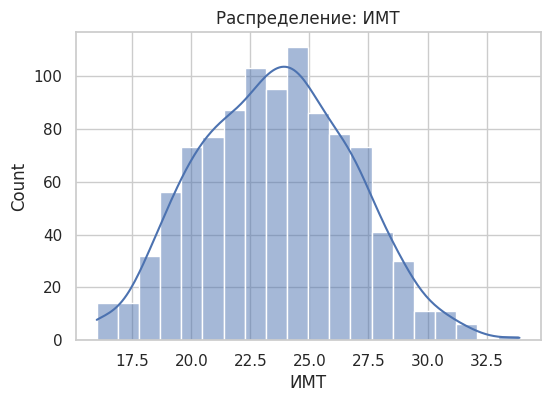

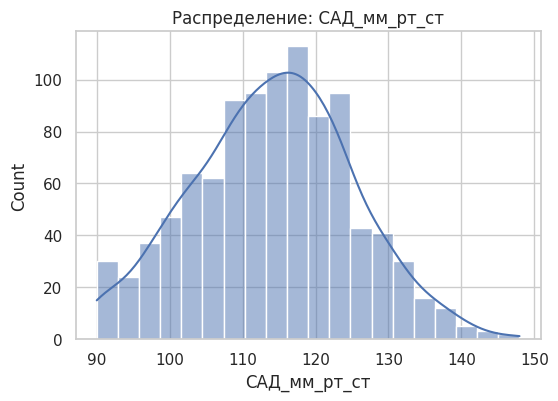

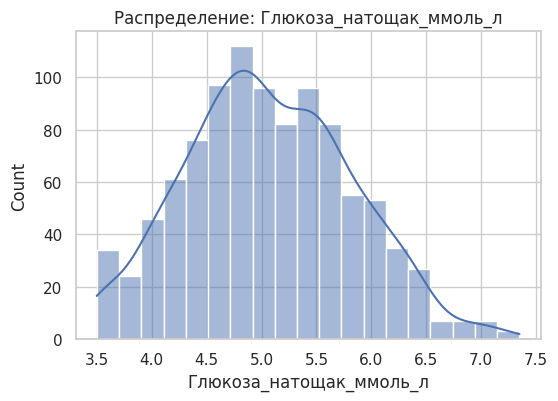

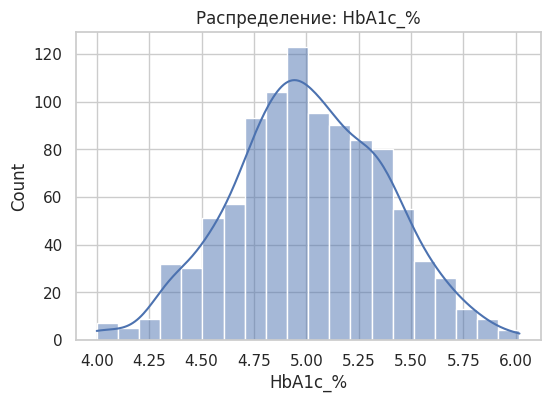

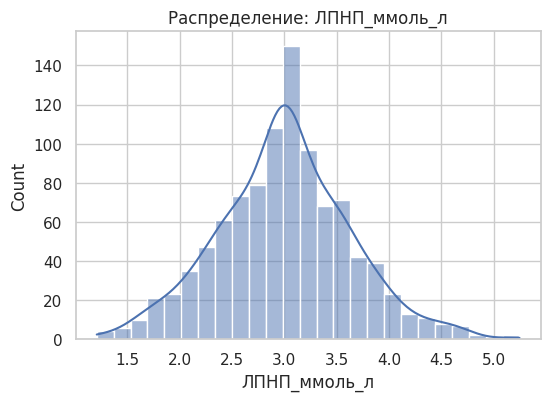

In [8]:

features = [
    'ИМТ',
    'САД_мм_рт_ст',
    'Глюкоза_натощак_ммоль_л',
    'HbA1c_%',
    'ЛПНП_ммоль_л'
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f'Распределение: {col}')

    plt.show()



## Вывод

По распределениям видно:
- часть пациентов имеет высокий ИМТ,
- у некоторых повышена глюкоза,
- наблюдаются повышенные значения HbA1c,
- присутствует высокий уровень ЛПНП.

Это может свидетельствовать о ранних метаболических нарушениях.



# Корреляционный анализ

Корреляционный анализ показывает взаимосвязи между признаками.

Для визуализации используется тепловая карта корреляций.


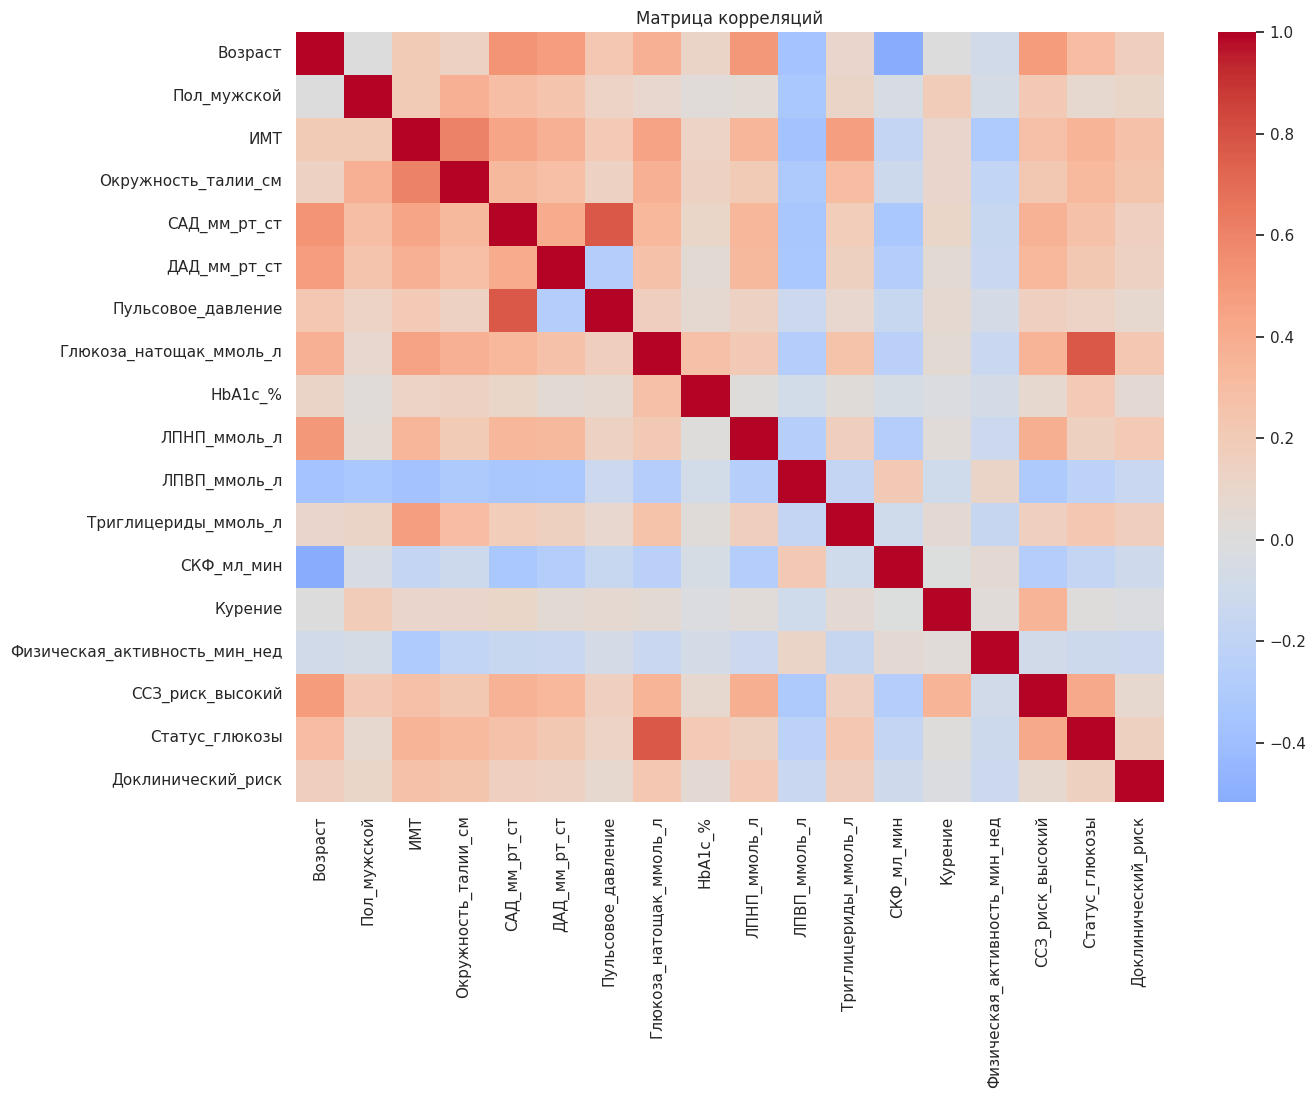

In [9]:

# Корреляционная матрица

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Матрица корреляций')

plt.show()



## Вывод

Были обнаружены ожидаемые взаимосвязи:
- ИМТ связан с окружностью талии,
- глюкоза связана с HbA1c,
- систолическое и диастолическое давление коррелируют между собой.

Это подтверждает существование скрытых метаболических профилей риска.



# Поиск пациентов с доклиническими нарушениями

На данном этапе создаётся индикатор скрытого риска.

Используются клинические критерии:
- повышенная глюкоза,
- повышенный HbA1c,
- ожирение,
- высокое давление.


In [10]:

# Формирование группы скрытого риска

df['Скрытый_риск'] = (
    (df['Глюкоза_натощак_ммоль_л'] > 5.6) |
    (df['HbA1c_%'] > 5.7) |
    (df['ИМТ'] > 30) |
    (df['САД_мм_рт_ст'] > 140)
).astype(int)

df['Скрытый_риск'].value_counts()


,count
Скрытый_риск,
0,730
1,270


In [11]:

# Просмотр пациентов группы риска

risk_patients = df[df['Скрытый_риск'] == 1]

risk_patients.head()


,Возраст,Пол_мужской,ИМТ,Окружность_талии_см,САД_мм_рт_ст,ДАД_мм_рт_ст,Пульсовое_давление,Глюкоза_натощак_ммоль_л,HbA1c_%,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Триглицериды_ммоль_л,СКФ_мл_мин,Курение,Физическая_активность_мин_нед,ССЗ_риск_высокий,Статус_глюкозы,Доклинический_риск,Скрытый_риск
6,59.0,1.0,24.452363,84.067578,129.118110,82.702583,46.415527,6.455766,4.802427,3.959981,1.405751,2.273886,89.740475,1.0,177.430651,1.0,2.0,0.0,1
8,52.0,0.0,24.228811,88.037032,109.076619,68.295031,40.781588,6.354934,5.178457,3.083121,1.238753,0.632344,106.132085,0.0,158.118757,0.0,2.0,0.0,1
11,53.0,1.0,23.218281,87.652787,125.623323,62.941191,62.682132,4.064768,5.749944,2.760657,1.615957,1.586544,96.823665,0.0,252.281837,0.0,0.0,0.0,1
13,65.0,0.0,28.953834,90.597802,123.801315,78.100363,45.700952,6.290747,4.590619,4.545219,1.575919,1.108247,75.987707,0.0,103.483795,1.0,2.0,0.0,1
22,65.0,1.0,26.293881,100.035309,140.258947,79.646402,60.612544,5.860197,4.868660,2.998957,1.374313,1.745134,82.583370,1.0,204.496507,1.0,1.0,0.0,1



## Вывод

Была выделена группа пациентов с вероятными доклиническими нарушениями.

У таких пациентов возможны:
- предиабет,
- метаболический синдром,
- начальная гипертензия.

Эти пациенты требуют дополнительного наблюдения.



# Анализ выбросов

Выбросы — это значения, сильно отличающиеся от остальных.

В медицинских данных выбросы могут указывать:
- на тяжёлые нарушения,
- пациентов высокого риска,
- ошибки измерений.


In [12]:

# Поиск выбросов через Z-score

numeric_cols = [
    'ИМТ',
    'САД_мм_рт_ст',
    'Глюкоза_натощак_ммоль_л',
    'HbA1c_%',
    'ЛПНП_ммоль_л'
]

z_scores = np.abs(zscore(df[numeric_cols]))

outliers = (z_scores > 3).any(axis=1)

print("Количество пациентов с выбросами:", outliers.sum())


Количество пациентов с выбросами: 7



## Вывод

Пациенты с выбросами могут относиться к группе повышенного риска.

Такие наблюдения особенно важны для профилактической медицины.



# PCA — Метод главных компонент

PCA используется для:
- уменьшения размерности,
- выявления скрытых структур,
- визуализации профилей пациентов.

Метод помогает представить многомерные данные в виде двух компонент.


In [13]:

# Признаки для PCA

pca_features = [
    'Возраст',
    'ИМТ',
    'Окружность_талии_см',
    'САД_мм_рт_ст',
    'ДАД_мм_рт_ст',
    'Глюкоза_натощак_ммоль_л',
    'HbA1c_%',
    'ЛПНП_ммоль_л',
    'Триглицериды_ммоль_л',
    'СКФ_мл_мин'
]

X = df[pca_features]

# Стандартизация данных

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    components,
    columns=['PC1', 'PC2']
)

pca_df['Скрытый_риск'] = df['Скрытый_риск']

print("PCA выполнен!")


PCA выполнен!


In [14]:

# Объяснённая дисперсия

print("Объяснённая дисперсия:")
print(pca.explained_variance_ratio_)


Объяснённая дисперсия:
[0.35749823 0.14603127]


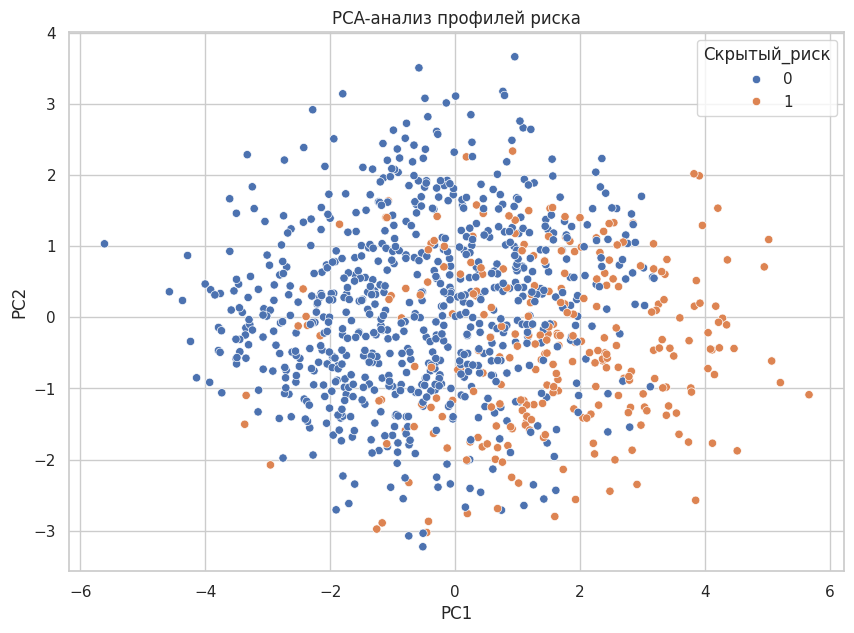

In [15]:

# Визуализация PCA

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Скрытый_риск'
)

plt.title('PCA-анализ профилей риска')

plt.show()



## Вывод

PCA показывает наличие различных скрытых профилей пациентов.

Пациенты со скрытым риском чаще располагаются в отдельных областях графика.

Это позволяет:
- выявлять ранние нарушения,
- оценивать метаболические риски,
- поддерживать принятие врачебных решений.



# ОБЩИЙ ВЫВОД
На практике мною  были:
- исследованы медицинские данные пациентов,
- проведён разведочный анализ данных,
- выявлены скрытые факторы риска,
- найдены пациенты с доклиническими нарушениями,
- применён метод главных компонент PCA.

## Практическая значимость

Полученные результаты могут использоваться:
- в профилактической медицине,
- при диспансерном наблюдении,
- для раннего выявления хронических заболеваний.

## Главный вывод
Я научилась пприменять метод главных компонет PCA поняла как строить и читать матрицу корреляций. Интересно было поработать над частью поиска пациентов с доклиническими нарушениями, ведь даже до появления выраженных симптомов можно выявлять пациентов с высоким риском заболеваний на основе анализа медицинских данных.
